# LBF EPyMARL Baselines

Runs Random, IQL, MAPPO, and QMIX for 1000 episodes on the requested Level-Based Foraging scenarios. Random is run locally; IQL, MAPPO, and QMIX are run through an external EPyMARL checkout.

In [1]:
import json
import re
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from discrete_action_space.lbf_grid.epymarl_baselines import (
    EPYMARL_ALGORITHMS,
    n_frames_for_episodes,
    run_epymarl_baseline,
    run_random_policy_baseline,
)
from discrete_action_space.lbf_grid.epymarl_lbf_env import EPYMARL_LBF_SCENARIOS


In [2]:
N_EPISODES = 1000
SCENARIOS = tuple(EPYMARL_LBF_SCENARIOS)

for key, scenario in EPYMARL_LBF_SCENARIOS.items():
    print(f"{key}: {scenario.description}")
    print(f"  gym_id={scenario.gym_id}")
    print(f"  EPyMARL t_max for {N_EPISODES} episodes = {n_frames_for_episodes(key, N_EPISODES)}")


lbf_8x8_2p_2f_levels12: 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes
  gym_id=SREDQNForaging-8x8-2p-2f-levels12-v0
  EPyMARL t_max for 1000 episodes = 50000
lbf_8x8_2p_2f_force_coop: 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes
  gym_id=SREDQNForaging-8x8-2p-2f-force-coop-v0
  EPyMARL t_max for 1000 episodes = 50000
lbf_10x10_3p_8f_levels123: 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes
  gym_id=SREDQNForaging-10x10-3p-8f-levels123-v0
  EPyMARL t_max for 1000 episodes = 100000


Set `EPYMARL_ROOT` to a local clone of `https://github.com/uoe-agents/epymarl`. Install EPyMARL dependencies in this same Python environment before running the cell below.

In [3]:
EPYMARL_ROOT = EPYMARL_ROOT = Path("/home/wowthecoder/epymarl")
OUTPUT_ROOT = REPO_ROOT / "discrete_action_space" / "lbf_grid" / "baseline_runs" / "epymarl"
SEED = 2025

if not (EPYMARL_ROOT / "src" / "main.py").exists():
    raise FileNotFoundError(
        f"Set EPYMARL_ROOT to a valid EPyMARL checkout. Missing: {EPYMARL_ROOT / 'src' / 'main.py'}"
    )

CONFIG_OVERRIDES = {
    "runner": "parallel",
    "batch_size_run": 64,
    "use_cuda": True,
    "test_nepisode": 20,
}


In [4]:
def print_stats(record):
    alg = record['algorithm'].upper()
    print(f"\n-- {alg} | {record['scenario_name']} --")
    print(f"  episodes : {record['n_episodes']:,}  |  t_max : {record['t_max']:,}  |  seed : {record['seed']}")
    stats_path = record.get('reward_stats_path') or record.get('stats_path')
    if stats_path and Path(stats_path).exists():
        payload = json.loads(Path(stats_path).read_text())
        reward_stats = payload.get('reward_statistics', {})
        for key, stats in reward_stats.items():
            final = stats.get('final')
            last_100 = stats.get('last_100_mean')
            if final is not None:
                print(f"  {key} final train reward : {final:.4f}")
            if last_100 is not None:
                print(f"  {key} last-100 mean      : {last_100:.4f}")
    else:
        status = 'OK' if record.get('returncode', 0) == 0 else f"FAILED (code {record['returncode']})"
        print(f"  status : {status}")


def plot_random_rewards(record):
    plot_epymarl_rewards(record)


def plot_epymarl_rewards(record):
    stats_path = record.get('reward_stats_path') or record.get('stats_path')
    if not stats_path or not Path(stats_path).exists():
        print('  [no saved reward artifacts found]')
        return
    payload = json.loads(Path(stats_path).read_text())
    curves = payload.get('reward_curve', {})
    episodes = curves.get('episodes')
    if not episodes:
        print('  [no reward curve data found]')
        return
    aggregate_labels = {'joint', 'total', 'shared'}
    has_agent_curves = any(label.startswith('agent_') and values for label, values in curves.items())
    fig, ax = plt.subplots(figsize=(10, 4))
    for label, values in curves.items():
        if label == 'episodes':
            continue
        if has_agent_curves and label in aggregate_labels:
            continue
        ax.plot(episodes, values, label=label.replace('_', ' ').title())
    ax.set_xlabel('Episode')
    ax.set_ylabel('Training reward')
    ax.set_title(f"{record['algorithm'].upper()} - {record['scenario_name']}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()



-- RANDOM | 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes --
  episodes : 1,000  |  t_max : 50,000  |  seed : 2025
  agent_0 final train reward : 0.0000
  agent_0 last-100 mean      : 0.0375
  agent_1 final train reward : 0.0000
  agent_1 last-100 mean      : 0.1288
  joint final train reward : 0.0000
  joint last-100 mean      : 0.1663


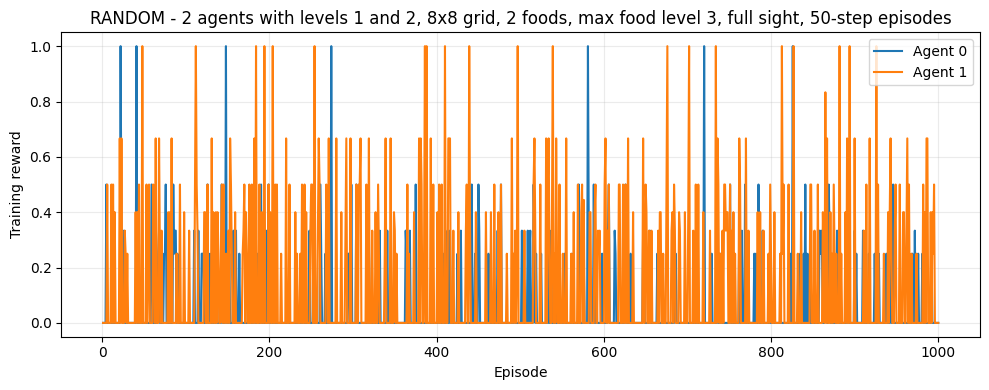


-- RANDOM | 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes --
  episodes : 1,000  |  t_max : 50,000  |  seed : 3025
  agent_0 final train reward : 0.0000
  agent_0 last-100 mean      : 0.0000
  agent_1 final train reward : 0.0000
  agent_1 last-100 mean      : 0.0000
  joint final train reward : 0.0000
  joint last-100 mean      : 0.0000


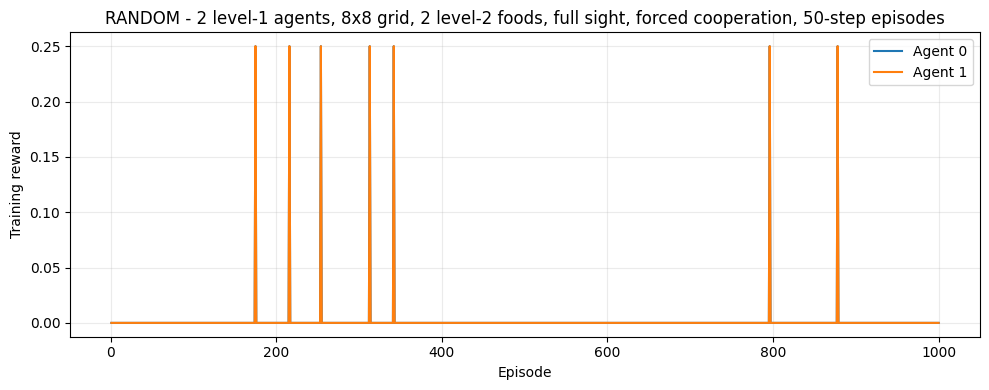


-- RANDOM | 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes --
  episodes : 1,000  |  t_max : 100,000  |  seed : 4025
  agent_0 final train reward : 0.0455
  agent_0 last-100 mean      : 0.0187
  agent_1 final train reward : 0.0000
  agent_1 last-100 mean      : 0.0674
  agent_2 final train reward : 0.2727
  agent_2 last-100 mean      : 0.1616
  joint final train reward : 0.3182
  joint last-100 mean      : 0.2477


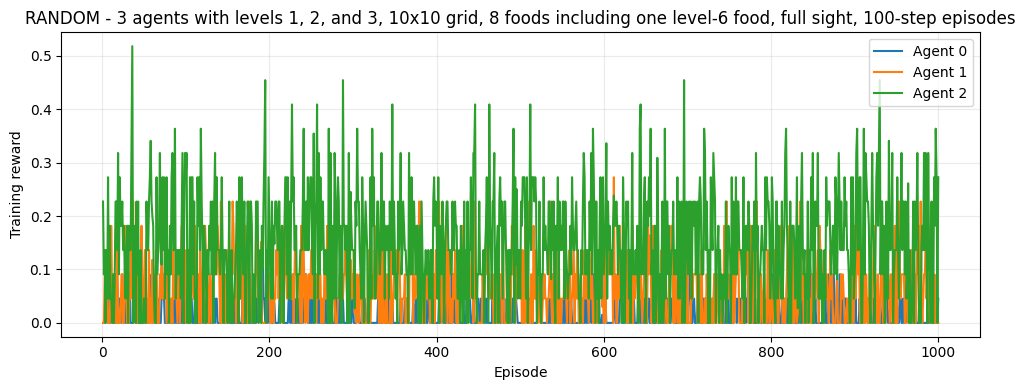

In [5]:
records_random = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_random_policy_baseline(
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i,
        output_root=OUTPUT_ROOT,
    )
    records_random.append(record)
    print_stats(record)
    plot_random_rewards(record)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
IQL lbf_8x8_2p_2f_levels12: 100%|██████████| 50000/50000 [00:25<00:00, 1959.25step/s]


-- IQL | 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes --
  episodes : 1,000  |  t_max : 50,000  |  seed : 2026
  agent_0 final train reward : 0.0680
  agent_0 last-100 mean      : 0.0696
  agent_1 final train reward : 0.1769
  agent_1 last-100 mean      : 0.1700
  total final train reward : 0.2449
  total last-100 mean      : 0.2395


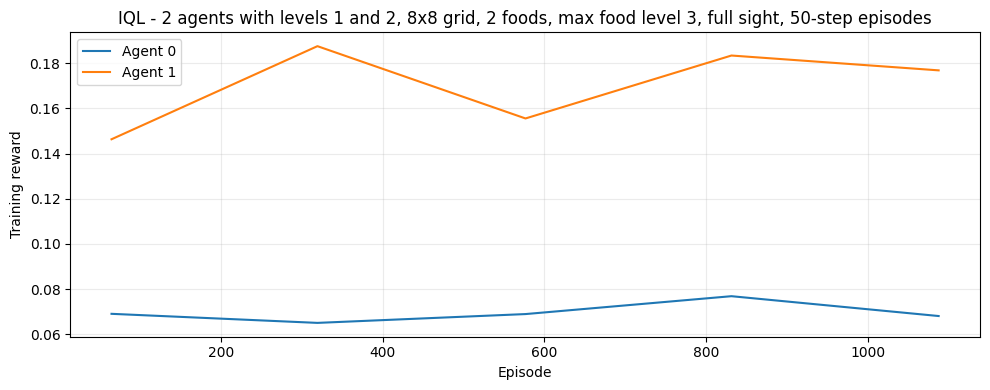

IQL lbf_8x8_2p_2f_force_coop: 100%|██████████| 50000/50000 [00:24<00:00, 2038.55step/s]



-- IQL | 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes --
  episodes : 1,000  |  t_max : 50,000  |  seed : 3026
  agent_0 final train reward : 0.0029
  agent_0 last-100 mean      : 0.0017
  agent_1 final train reward : 0.0029
  agent_1 last-100 mean      : 0.0017
  total final train reward : 0.0059
  total last-100 mean      : 0.0034


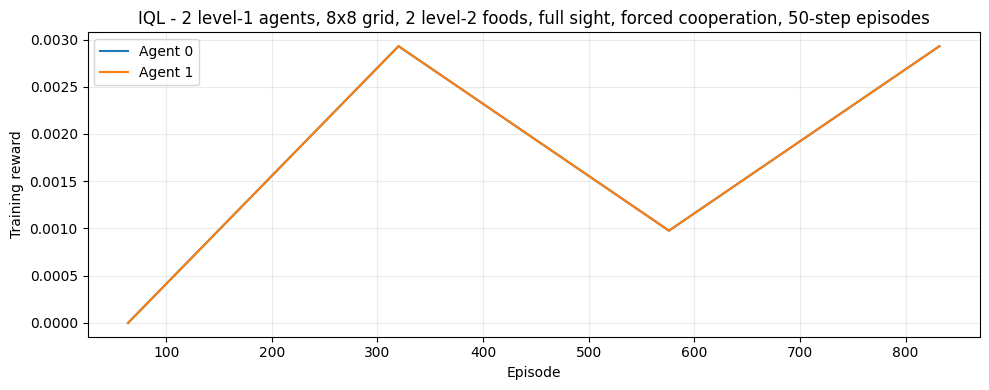

IQL lbf_10x10_3p_8f_levels123: 100%|██████████| 100000/100000 [00:41<00:00, 2407.31step/s]



-- IQL | 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes --
  episodes : 1,000  |  t_max : 100,000  |  seed : 4026
  agent_0 final train reward : 0.0217
  agent_0 last-100 mean      : 0.0199
  agent_1 final train reward : 0.0666
  agent_1 last-100 mean      : 0.0715
  agent_2 final train reward : 0.1340
  agent_2 last-100 mean      : 0.1568
  total final train reward : 0.2223
  total last-100 mean      : 0.2483


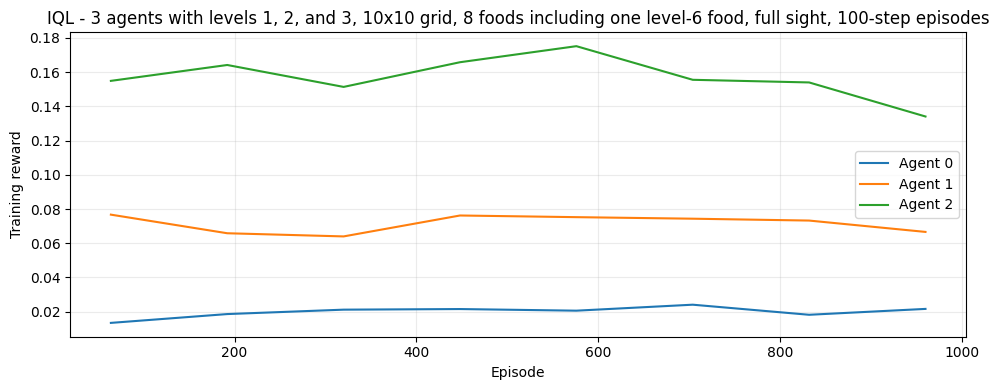

In [6]:
records_iql = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'iql',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 1,
        output_root=OUTPUT_ROOT,
        common_reward=False,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_iql.append(record)
    print_stats(record)
    plot_epymarl_rewards(record)


MAPPO lbf_8x8_2p_2f_levels12: 100%|██████████| 50000/50000 [00:31<00:00, 1585.17step/s]



-- MAPPO | 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes --
  episodes : 1,000  |  t_max : 50,000  |  seed : 2027
  agent_0 final train reward : 0.0696
  agent_0 last-100 mean      : 0.0613
  agent_1 final train reward : 0.1710
  agent_1 last-100 mean      : 0.1758
  total final train reward : 0.2406
  total last-100 mean      : 0.2371


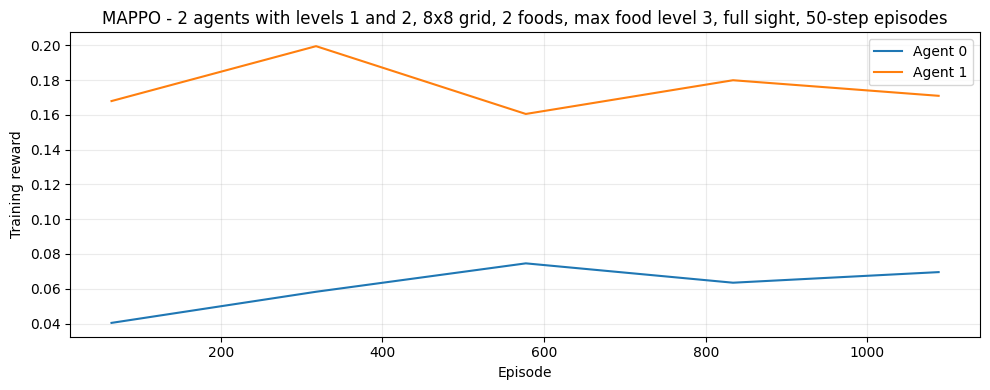

MAPPO lbf_8x8_2p_2f_force_coop: 100%|██████████| 50000/50000 [00:31<00:00, 1585.96step/s]



-- MAPPO | 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes --
  episodes : 1,000  |  t_max : 50,000  |  seed : 3027
  agent_0 final train reward : 0.0000
  agent_0 last-100 mean      : 0.0002
  agent_1 final train reward : 0.0000
  agent_1 last-100 mean      : 0.0002
  total final train reward : 0.0000
  total last-100 mean      : 0.0005


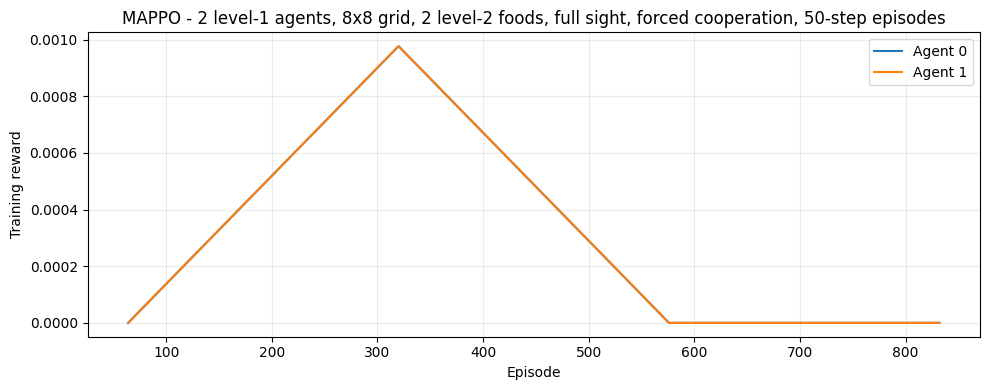

MAPPO lbf_10x10_3p_8f_levels123: 100%|██████████| 100000/100000 [00:54<00:00, 1850.54step/s]



-- MAPPO | 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes --
  episodes : 1,000  |  t_max : 100,000  |  seed : 4027
  agent_0 final train reward : 0.0275
  agent_0 last-100 mean      : 0.0216
  agent_1 final train reward : 0.0965
  agent_1 last-100 mean      : 0.0690
  agent_2 final train reward : 0.1875
  agent_2 last-100 mean      : 0.1431
  total final train reward : 0.3114
  total last-100 mean      : 0.2337


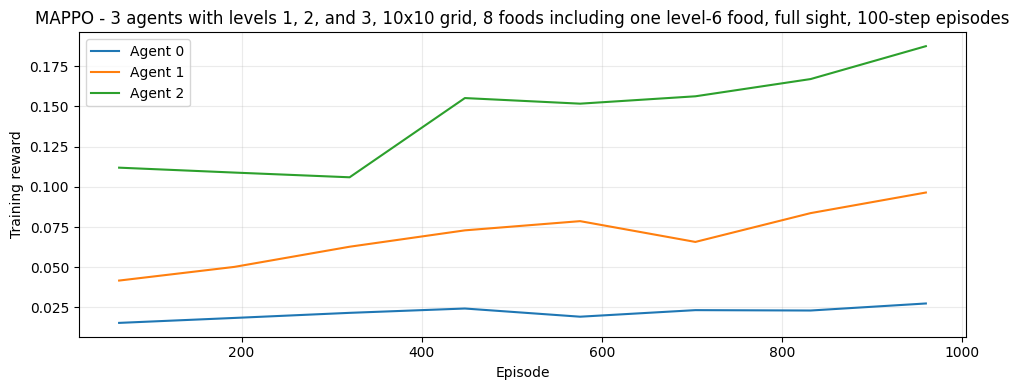

In [7]:
records_mappo = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'mappo',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 2,
        output_root=OUTPUT_ROOT,
        common_reward=False,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_mappo.append(record)
    print_stats(record)
    plot_epymarl_rewards(record)


QMIX lbf_8x8_2p_2f_levels12: 100%|██████████| 50000/50000 [00:24<00:00, 2039.33step/s]


-- QMIX | 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes --
  episodes : 1,000  |  t_max : 50,000  |  seed : 2028
  shared final train reward : 0.1314
  shared last-100 mean      : 0.1756


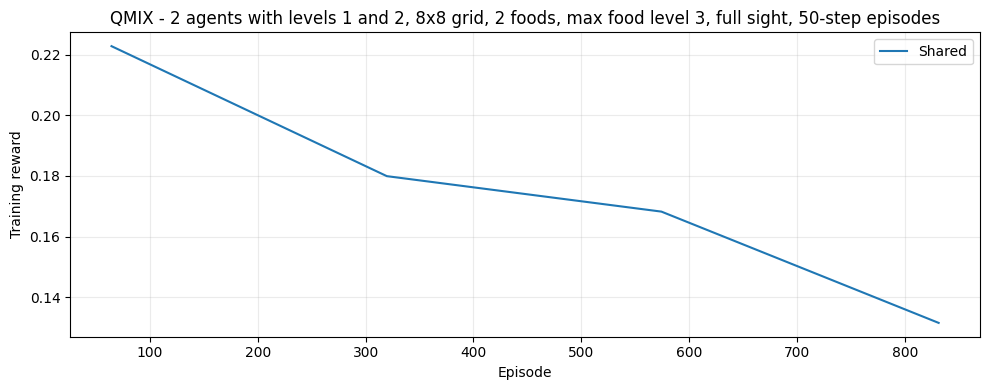

QMIX lbf_8x8_2p_2f_force_coop: 100%|██████████| 50000/50000 [00:24<00:00, 2081.93step/s]



-- QMIX | 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes --
  episodes : 1,000  |  t_max : 50,000  |  seed : 3028
  shared final train reward : 0.0234
  shared last-100 mean      : 0.0132


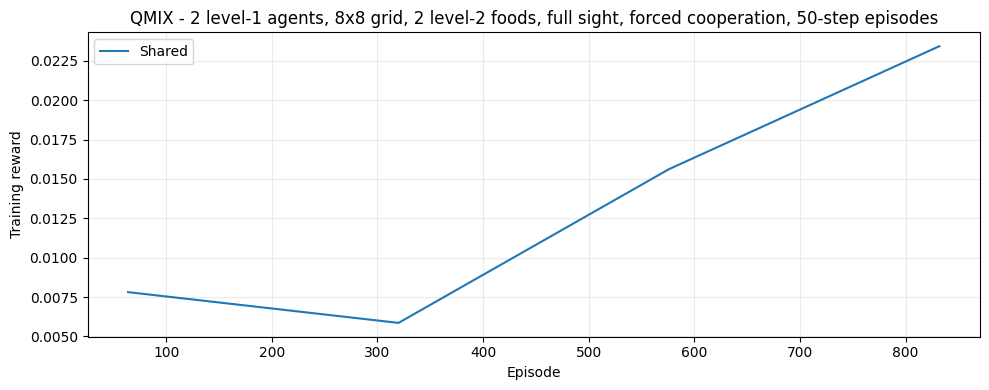

QMIX lbf_10x10_3p_8f_levels123: 100%|██████████| 100000/100000 [00:40<00:00, 2466.97step/s]


-- QMIX | 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes --
  episodes : 1,000  |  t_max : 100,000  |  seed : 4028
  shared final train reward : 0.0462
  shared last-100 mean      : 0.1110


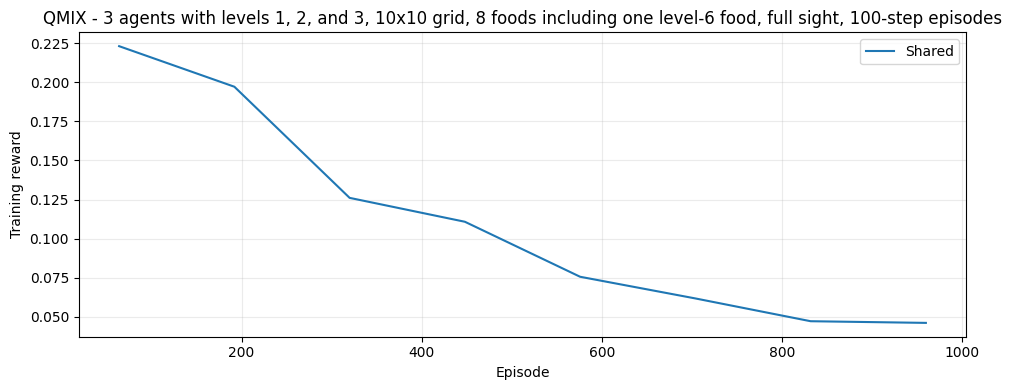

In [8]:
records_qmix = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'qmix',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 3,
        output_root=OUTPUT_ROOT,
        common_reward=True,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_qmix.append(record)
    print_stats(record)
    plot_epymarl_rewards(record)
